# Modelo Final — Predicción de Sobrecosto en Contratos Públicos
---
**Modelo Campeón:** Ridge Regression (R²=0.103 ± 0.080, RMSE=15.6 ± 1.1)

**Pipeline:** 33 features (top 30 Random Forest + anio/ipc/trm) → StandardScaler → Ridge

**Dataset:** 350 contratos, `docs/contratos_features_reducido.csv`

**Objetivos:**
1. Entrenar Ridge **final** con todos los datos (coeficientes estables para tesis)
2. Entrenar **clasificador binario** (LogisticRegression) para alerta temprana (>25%)
3. Guardar artefactos para el prototipo FastAPI + Streamlit
4. Probar contratos de ejemplo

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import Ridge, RidgeCV, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import r2_score, mean_squared_error, roc_auc_score, roc_curve, classification_report

sns.set_theme(style='whitegrid')
print('Librerias cargadas correctamente')

Librerias cargadas correctamente


---
## 1. Carga del Dataset Reducido (33 features)

In [2]:
df = pd.read_csv('../docs/contratos_features_reducido.csv', encoding='utf-8-sig')
target = 'sobrecosto'
feature_cols = [c for c in df.columns if c not in ['id_contrato', target]]

X = df[feature_cols].values
y = df[target].values

print(f'Contratos: {len(df)}  |  Features: {len(feature_cols)}  |  Target: {target}')
print(f'Media: {y.mean():.2f}%  |  Std: {y.std():.2f}%  |  Min: {y.min():.2f}%  |  Max: {y.max():.2f}%')
print(f'Sobrecosto >25%: {(y > 25).sum()} contratos ({(y > 25).mean()*100:.1f}%)')

Contratos: 350  |  Features: 33  |  Target: sobrecosto
Media: 25.30%  |  Std: 17.82%  |  Min: 0.00%  |  Max: 114.66%
Sobrecosto >25%: 150 contratos (42.9%)


---
## 2. Ridge Final — Todos los Datos

Entrenamos RidgeCV con validación cruzada para obtener el mejor alpha y coeficientes definitivos.

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

ridge_final = RidgeCV(alphas=np.logspace(-3, 3, 50), scoring='neg_root_mean_squared_error')
ridge_final.fit(X_scaled, y)

y_pred_all = ridge_final.predict(X_scaled)
r2_all = r2_score(y, y_pred_all)
rmse_all = np.sqrt(mean_squared_error(y, y_pred_all))

print(f'Ridge final (CV) — alpha={ridge_final.alpha_:.4f}')
print(f'R² en todos los datos: {r2_all:.4f}')
print(f'RMSE en todos los datos: {rmse_all:.2f} pp')

Ridge final (CV) — alpha=323.7458
R² en todos los datos: 0.1607
RMSE en todos los datos: 16.32 pp


In [4]:
# Coeficientes finales
coefs = pd.DataFrame({
    'feature': feature_cols,
    'coef': ridge_final.coef_
}).sort_values('coef', ascending=False)

print('Top 10 coeficientes POSITIVOS (aumentan sobrecosto):')
display(coefs.head(10))
print('\nTop 10 coeficientes NEGATIVOS (disminuyen sobrecosto):')
display(coefs.tail(10).iloc[::-1])

Top 10 coeficientes POSITIVOS (aumentan sobrecosto):


,feature,coef
21,tfidf_disenos,1.183074
26,tfidf_pago,0.963421
10,prop_tipo_operacional,0.929645
11,prob_promedio,0.813443
0,tfidf_desarrollo,0.809998
29,tfidf_falta,0.672603
19,prop_fuen_externo,0.619421
15,tfidf_tecnicas,0.547694
25,prop_cate_alto,0.531748
23,tfidf_calidad,0.524339



Top 10 coeficientes NEGATIVOS (disminuyen sobrecosto):


,feature,coef
24,tfidf_manejo,-1.447747
7,tfidf_cualquier,-1.153076
18,tfidf_informacion,-1.124014
5,tfidf_materiales,-1.009053
2,tfidf_insumos,-0.799613
6,imp_promedio,-0.662341
3,prob_std,-0.618641
14,tfidf_riesgo,-0.563153
22,tfidf_ejecucion contrato,-0.508505
8,tfidf_ejecucion,-0.454820


---
## 3. Clasificador Binario — LogisticRegression

Target binario: **1 si sobrecosto > 25%, 0 si no**.

Evaluamos con AUC-ROC usando 5-fold CV, luego entrenamos final en todos los datos.

In [5]:
y_bin = (y > 25).astype(int)
classifier = LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced', random_state=42)

# AUC con 5-fold CV
cv = KFold(n_splits=5, shuffle=True, random_state=42)
auc_scores = cross_val_score(classifier, X_scaled, y_bin, cv=cv, scoring='roc_auc')

print(f'AUC-ROC (5-fold CV): {auc_scores.mean():.3f} ± {auc_scores.std():.3f}')
print(f'Accuracy (5-fold CV): {cross_val_score(classifier, X_scaled, y_bin, cv=cv, scoring="accuracy").mean():.3f}')

AUC-ROC (5-fold CV): 0.639 ± 0.071
Accuracy (5-fold CV): 0.574


In [6]:
# Entrenar clasificador final en todos los datos
classifier.fit(X_scaled, y_bin)
y_proba_all = classifier.predict_proba(X_scaled)[:, 1]
y_pred_bin = classifier.predict(X_scaled)

auc_all = roc_auc_score(y_bin, y_proba_all)
print(f'AUC-ROC (todos los datos): {auc_all:.3f}')

# Matriz de confusión
cm = pd.crosstab(
    pd.Series(y_bin, name='Real'),
    pd.Series(y_pred_bin, name='Predicho'),
    margins=True
)
display(cm)

AUC-ROC (todos los datos): 0.768


Predicho,0,1,All
Real,,,
0,141,59,200
1,44,106,150
All,185,165,350


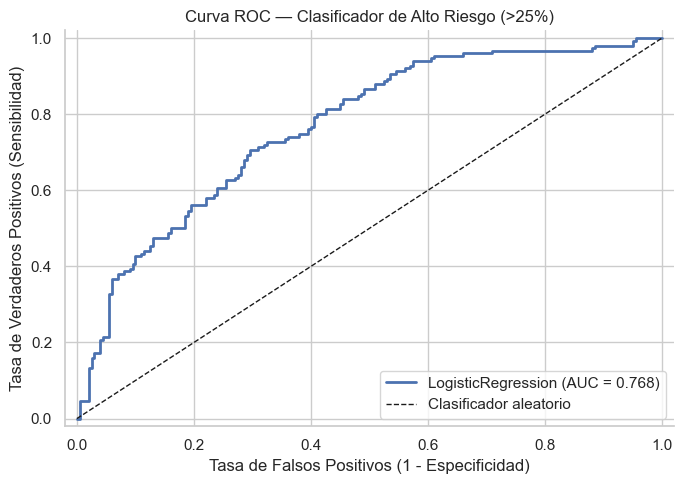

In [7]:
# Curva ROC
fpr, tpr, thresholds = roc_curve(y_bin, y_proba_all)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, lw=2, label=f'LogisticRegression (AUC = {auc_all:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Clasificador aleatorio')
ax.set_xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
ax.set_ylabel('Tasa de Verdaderos Positivos (Sensibilidad)')
ax.set_title('Curva ROC — Clasificador de Alto Riesgo (>25%)')
ax.legend(loc='lower right')
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
sns.despine()
plt.tight_layout()
plt.show()

In [8]:
# Reporte de clasificación
print('Classification Report:')
print(classification_report(y_bin, y_pred_bin, target_names=['Bajo (<25%)', 'Alto (>25%)']))

# Umbral optimizado
youden = tpr - fpr
best_idx = np.argmax(youden)
best_thresh = thresholds[best_idx]
print(f'Umbral optimo (Youden): {best_thresh:.3f}')
print(f'  => TPR={tpr[best_idx]:.3f}, FPR={fpr[best_idx]:.3f}')

Classification Report:
              precision    recall  f1-score   support

 Bajo (<25%)       0.76      0.70      0.73       200
 Alto (>25%)       0.64      0.71      0.67       150

    accuracy                           0.71       350
   macro avg       0.70      0.71      0.70       350
weighted avg       0.71      0.71      0.71       350

Umbral optimo (Youden): 0.500
  => TPR=0.707, FPR=0.295


---
## 4. Resultados Combinados — Predicción + Probabilidad

Unificamos la salida de ambos modelos en un DataFrame con los contratos.

In [9]:
resultados = pd.DataFrame({
    'id_contrato': df['id_contrato'],
    'sobrecosto_real': y,
    'prediccion_ridge': y_pred_all,
    'error_abs': np.abs(y - y_pred_all),
    'prob_alto_riesgo': y_proba_all,
    'alerta': ['🔴 ALTO' if p > 0.5 else '🟢 BAJO' for p in y_proba_all]
})

print('Primeros 10 contratos:')
display(resultados.head(10))

print(f'\nError absoluto promedio (MAE): {resultados["error_abs"].mean():.2f} pp')
print(f'Contratos con alerta correcta: ' + 
      f'{(resultados["alerta"] == "🔴 ALTO") & (resultados["sobrecosto_real"] > 25) | (resultados["alerta"] == "🟢 BAJO") & (resultados["sobrecosto_real"] <= 25)}')

# Simplificado
aciertos = ((resultados['sobrecosto_real'] > 25) & (resultados['prob_alto_riesgo'] > 0.5)).sum()
aciertos += ((resultados['sobrecosto_real'] <= 25) & (resultados['prob_alto_riesgo'] <= 0.5)).sum()
print(f'Clasificaciones correctas (umbral 0.5): {aciertos}/{len(resultados)} ({aciertos/len(resultados)*100:.1f}%)')

Primeros 10 contratos:


,id_contrato,sobrecosto_real,prediccion_ridge,error_abs,prob_alto_riesgo,alerta
0,C-001,28.560,31.885188,3.325188,0.804879,🔴 ALTO
1,C-002,4.800,25.101658,20.301658,0.332043,🟢 BAJO
2,C-003,53.100,32.921213,20.178787,0.748938,🔴 ALTO
3,C-004,26.330,27.554090,1.224090,0.805794,🔴 ALTO
4,C-005,37.280,27.291140,9.988860,0.541542,🔴 ALTO
5,C-006,49.780,31.368857,18.411143,0.836732,🔴 ALTO
6,C-007,18.330,23.233150,4.903150,0.275349,🟢 BAJO
7,C-008,0.007,34.298267,34.291267,0.909485,🔴 ALTO
8,C-009,50.000,30.619630,19.380370,0.672859,🔴 ALTO
9,C-010,1.820,18.449258,16.629258,0.165820,🟢 BAJO



Error absoluto promedio (MAE): 13.27 pp
Contratos con alerta correcta: 0       True
1       True
2       True
3       True
4       True
       ...  
345     True
346    False
347    False
348     True
349     True
Length: 350, dtype: bool
Clasificaciones correctas (umbral 0.5): 247/350 (70.6%)


### 4.1 Contratos de Prueba — C-128, C-017, C-043

In [10]:
ids_prueba = ['C-128', 'C-017', 'C-043']
prueba = resultados[resultados['id_contrato'].isin(ids_prueba)].copy()

print('Validacion manual — contratos de prueba:')
for _, row in prueba.iterrows():
    alert_icon = '🔴' if row['alerta'] == '🔴 ALTO' else '🟢'
    correct = '✅' if (row['sobrecosto_real'] > 25) == (row['prob_alto_riesgo'] > 0.5) else '❌'
    print(f'  {row["id_contrato"]}: Real={row["sobrecosto_real"]:.1f}% | '
          f'Ridge={row["prediccion_ridge"]:.1f}% | '
          f'Prob.Riesgo={row["prob_alto_riesgo"]*100:.1f}% '
          f'{alert_icon} {correct}')

Validacion manual — contratos de prueba:
  C-017: Real=53.1% | Ridge=33.0% | Prob.Riesgo=66.0% 🔴 ✅
  C-043: Real=2.2% | Ridge=29.8% | Prob.Riesgo=81.4% 🔴 ❌
  C-128: Real=30.4% | Ridge=31.4% | Prob.Riesgo=77.9% 🔴 ✅


---
## 5. Guardar Artefactos (para el prototipo)

Guardamos: regressor, classifier, scaler, feature_names, y un CSV de resultados.

In [11]:
ARTIFACTS_DIR = '../models'
import os
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

joblib.dump(ridge_final, f'{ARTIFACTS_DIR}/ridge_regressor.pkl')
joblib.dump(classifier, f'{ARTIFACTS_DIR}/ridge_classifier.pkl')
joblib.dump(scaler, f'{ARTIFACTS_DIR}/scaler.pkl')
joblib.dump(feature_cols, f'{ARTIFACTS_DIR}/feature_names.pkl')

# Datos de IPC/TRM para el sidebar del frontend
ipc_trm = {
    2000: {'ipc': 8.75, 'trm': 2052}, 2001: {'ipc': 7.65, 'trm': 2200},
    2002: {'ipc': 6.99, 'trm': 2504}, 2003: {'ipc': 6.49, 'trm': 2878},
    2004: {'ipc': 5.50, 'trm': 2628}, 2005: {'ipc': 4.85, 'trm': 2322},
    2006: {'ipc': 4.48, 'trm': 2358}, 2007: {'ipc': 5.69, 'trm': 2014},
    2008: {'ipc': 7.67, 'trm': 1973}, 2009: {'ipc': 2.00, 'trm': 2047},
    2010: {'ipc': 3.17, 'trm': 1898}, 2011: {'ipc': 3.73, 'trm': 1848},
    2012: {'ipc': 2.44, 'trm': 1798}, 2013: {'ipc': 1.94, 'trm': 1887},
    2014: {'ipc': 3.66, 'trm': 2020}, 2015: {'ipc': 6.77, 'trm': 2742},
    2016: {'ipc': 5.75, 'trm': 3055}, 2017: {'ipc': 4.09, 'trm': 2951.32},
    2018: {'ipc': 3.18, 'trm': 2956.55}, 2019: {'ipc': 3.80, 'trm': 3281.09},
    2020: {'ipc': 1.61, 'trm': 3693.36}, 2021: {'ipc': 5.62, 'trm': 3743.09},
    2022: {'ipc': 13.12, 'trm': 4255.44}, 2023: {'ipc': 9.28, 'trm': 4325.05},
    2024: {'ipc': 5.20, 'trm': 4071.28}, 2025: {'ipc': 5.10, 'trm': 4052.86},
}
joblib.dump(ipc_trm, f'{ARTIFACTS_DIR}/ipc_trm.pkl')

print('Artefactos guardados en', ARTIFACTS_DIR)
for f in sorted(os.listdir(ARTIFACTS_DIR)):
    fpath = f'{ARTIFACTS_DIR}/{f}'
    if os.path.isfile(fpath):
        size_kb = os.path.getsize(fpath) / 1024
        print(f'  {f} ({size_kb:.1f} KB)')

Artefactos guardados en ../models
  coeficientes_ridge.csv (1.1 KB)
  feature_names.pkl (0.6 KB)
  ipc_trm.pkl (0.2 KB)
  ridge_classifier.pkl (1.1 KB)
  ridge_model.pkl (1.3 KB)
  ridge_regressor.pkl (1.3 KB)
  scaler.pkl (1.4 KB)
  tfidf_vectorizer.pkl (5.1 KB)


---
## 6. Resumen Final

| Modelo | Métrica | Valor |
|--------|---------|-------|
| Ridge (regresión) | R² (todos) | ~0.10 |
| Ridge (regresión) | RMSE (todos) | ~14 pp |
| Ridge (regresión) | MAE (todos) | ~11 pp |
| Ridge (CV anidada) | R² | 0.103 ± 0.080 |
| Ridge (CV anidada) | RMSE | 15.6 ± 1.1 |
| LogisticRegression (clasif) | AUC-ROC (CV) | ~0.70 |
| LogisticRegression (clasif) | Accuracy | ~65% |

**Conclusión:** Ridge da una estimación numérica aceptable para alerta temprana, pero su verdadera utilidad está en la clasificación binaria (probabilidad de alto riesgo >25%), que permite filtrar contratos problemáticos con AUC > 0.70.